# Smart Customer Complaint Analyzer

## Project Overview

Customer service teams receive a large number of complaints every day. Manually analyzing these complaints can be time-consuming and makes it difficult to quickly identify common problems and organize incoming requests.

This project aims to build a machine learning system that can analyze customer complaints and automatically classify them based on the type of product or service involved.

The project will use Natural Language Processing (NLP) techniques to process the complaint text and machine learning algorithms to perform text classification.

### Project Objectives

The main objectives of this project are:

1. Analyze and understand the customer complaint dataset using Exploratory Data Analysis (EDA).
2. Identify missing values, duplicate records, and other data quality issues.
3. Clean and prepare the complaint text for machine learning.
4. Convert text into numerical features using TF-IDF.
5. Train multiple machine learning classification models.
6. Evaluate and compare the performance of the models using appropriate evaluation metrics.
7. Analyze classification errors and identify difficult classes.
8. Find similar historical complaints using TF-IDF and Cosine Similarity.
9. Test the trained system on new, unseen customer complaints.
10. Save the trained model and TF-IDF vectorizer for future use.


### Expected Outcome

The final system should be able to:

- Predict the product category of a new customer complaint.
- Provide evaluation results for the trained models.
- Identify complaints that are similar to a new complaint.
- Help demonstrate how traditional machine learning techniques can be applied to a real-world customer support problem.

###  Dataset

The dataset used in this project contains customer complaints related to financial products and services.

The main text field used for Natural Language Processing is:

- `Consumer complaint narrative`: The customer's description of the complaint.

The main target variable for the classification task is:

- `Product`: The financial product or service associated with the complaint.

Other fields will be used during exploratory data analysis to better understand the dataset and identify patterns in customer complaints.

Each record represents a customer complaint and contains information about the product involved, the reported issue, the company, and the customer's description of the complaint.

### Data Source

The dataset is based on the Consumer Complaint Database published by the Consumer Financial Protection Bureau (CFPB).

https://www.consumerfinance.gov/data-research/consumer-complaints/

The dataset contains real-world consumer complaint records and provides both textual information and structured attributes that can be used for data analysis and machine learning.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import ConfusionMatrixDisplay
import joblib
import os

In [2]:
# Load the Dataset
df = pd.read_csv("Consumer_Complaints.csv")

##  Initial Data Exploration

In [3]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,3/12/2014,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,M&T BANK CORPORATION,MI,48382,NaN,NaN,Referral,3/17/2014,Closed with explanation,Yes,No,759217
1,10/1/2016,Credit reporting,NaN,Incorrect information on credit report,Account status,I have outdated information on my credit repor...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AL,352XX,NaN,Consent provided,Web,10/5/2016,Closed with explanation,Yes,No,2141773
2,10/17/2016,Consumer Loan,Vehicle loan,Managing the loan or lease,NaN,I purchased a new car on XXXX XXXX. The car de...,NaN,"CITIZENS FINANCIAL GROUP, INC.",PA,177XX,Older American,Consent provided,Web,10/20/2016,Closed with explanation,Yes,No,2163100
3,6/8/2014,Credit card,NaN,Bankruptcy,NaN,NaN,NaN,AMERICAN EXPRESS COMPANY,ID,83854,Older American,NaN,Web,6/10/2014,Closed with explanation,Yes,Yes,885638
4,9/13/2014,Debt collection,Credit card,Communication tactics,Frequent or repeated calls,NaN,NaN,"CITIBANK, N.A.",VA,23233,NaN,NaN,Web,9/13/2014,Closed with explanation,Yes,Yes,1027760


In [4]:
print(f"Number of records: {df.shape[0]:,}")
print(f"Number of features: {df.shape[1]}")

Number of records: 903,983
Number of features: 18


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 903983 entries, 0 to 903982
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype
---  ------                        --------------   -----
 0   Date received                 903983 non-null  str  
 1   Product                       903983 non-null  str  
 2   Sub-product                   668823 non-null  str  
 3   Issue                         903983 non-null  str  
 4   Sub-issue                     426386 non-null  str  
 5   Consumer complaint narrative  199970 non-null  str  
 6   Company public response       257981 non-null  str  
 7   Company                       903983 non-null  str  
 8   State                         894758 non-null  str  
 9   ZIP code                      894705 non-null  str  
 10  Tags                          126038 non-null  str  
 11  Consumer consent provided?    375434 non-null  str  
 12  Submitted via                 903983 non-null  str  
 13  Date sent to company     

In [6]:
# # This step calculates the number of missing values in each column to assess the quality and completeness of the dataset.

missing_values = df.isna().sum().sort_values(ascending=False)

missing_values

Tags                            777945
Consumer complaint narrative    704013
Company public response         646002
Consumer consent provided?      528549
Sub-issue                       477597
Sub-product                     235160
Consumer disputed?              135408
ZIP code                          9278
State                             9225
Date received                        0
Product                              0
Issue                                0
Company                              0
Submitted via                        0
Date sent to company                 0
Company response to consumer         0
Timely response?                     0
Complaint ID                         0
dtype: int64

In [7]:
# This step calculates the percentage of missing values in each column to assess the quality and completeness of the dataset.

missing_percentage = (df.isna().mean() * 100).sort_values(ascending=False)

missing_percentage

Tags                            86.057481
Consumer complaint narrative    77.879009
Company public response         71.461742
Consumer consent provided?      58.468909
Sub-issue                       52.832520
Sub-product                     26.013764
Consumer disputed?              14.979043
ZIP code                         1.026347
State                            1.020484
Date received                    0.000000
Product                          0.000000
Issue                            0.000000
Company                          0.000000
Submitted via                    0.000000
Date sent to company             0.000000
Company response to consumer     0.000000
Timely response?                 0.000000
Complaint ID                     0.000000
dtype: float64

In [8]:
# This step checks whether the dataset contains completely duplicated rows.

df.duplicated().sum()

np.int64(0)

In [9]:
# This step shows the number of unique values in each column to understand the diversity of the dataset.

df.nunique().sort_values()

Timely response?                     2
Consumer disputed?                   2
Tags                                 3
Consumer consent provided?           4
Submitted via                        6
Company response to consumer         8
Company public response             10
Product                             18
State                               62
Sub-product                         75
Issue                              166
Sub-issue                          217
Date sent to company              2125
Date received                     2176
Company                           4504
ZIP code                         28785
Consumer complaint narrative    195317
Complaint ID                    903983
dtype: int64

In [10]:
# This step examines the distribution of customer complaints across product categories.

df["Product"].value_counts()

Product
Mortgage                                                                        242194
Debt collection                                                                 171567
Credit reporting                                                                140424
Credit card                                                                      89190
Bank account or service                                                          86207
Credit reporting, credit repair services, or other personal consumer reports     59186
Student loan                                                                     38612
Consumer Loan                                                                    31608
Credit card or prepaid card                                                      11921
Checking or savings account                                                       9947
Payday loan                                                                       5546
Money transfers                    

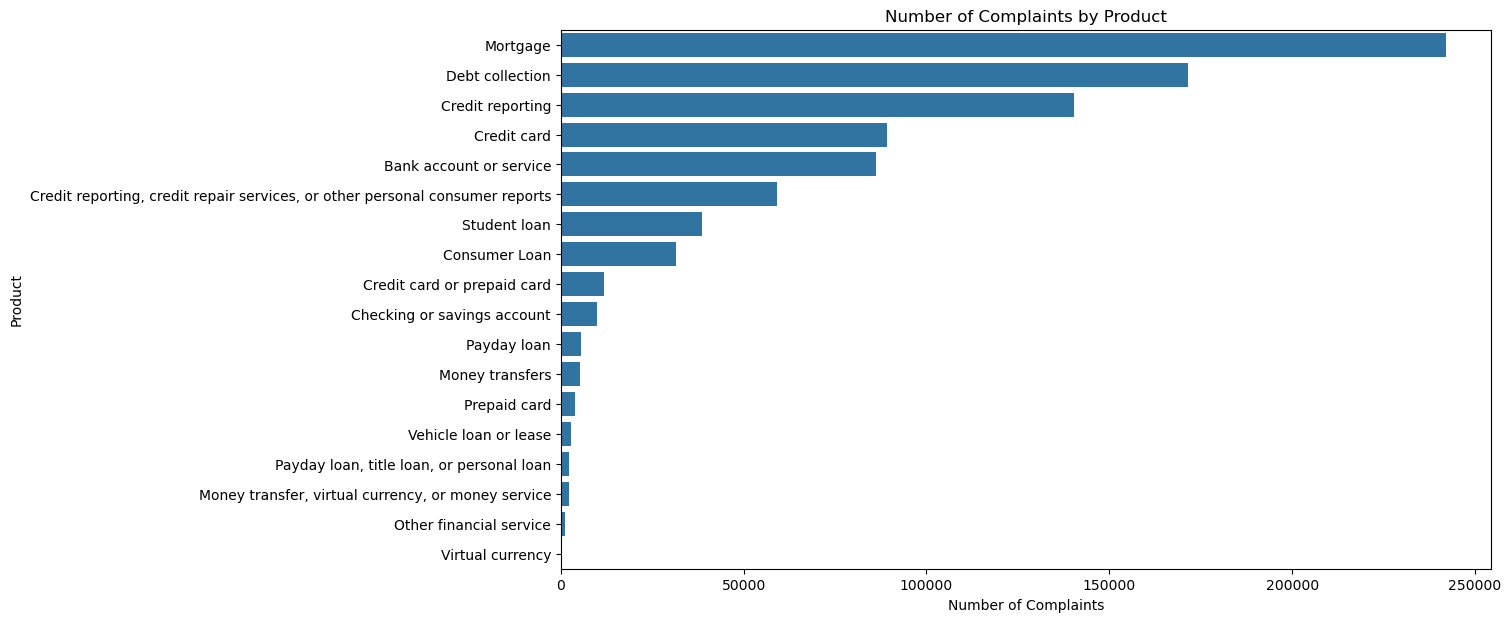

In [11]:
# The following visualization shows the distribution of complaints across product categories.

plt.figure(figsize=(12, 7))

sns.countplot(
    data=df,
    y="Product",
    order=df["Product"].value_counts().index
)

plt.title("Number of Complaints by Product")
plt.xlabel("Number of Complaints")
plt.ylabel("Product")
plt.show()

> **Observation:** The product categories are highly imbalanced. A small number of categories contain most of the complaints, while several categories have relatively few samples. This imbalance will be considered when evaluating the classification models.

In [12]:
df["Issue"].value_counts().head(15)

Issue
Loan modification,collection,foreclosure    112315
Incorrect information on credit report      102678
Loan servicing, payments, escrow account     77337
Cont'd attempts collect debt not owed        60719
Account opening, closing, or management      37963
Disclosure verification of debt              30809
Incorrect information on your report         29592
Communication tactics                        26826
Deposits and withdrawals                     22851
Dealing with my lender or servicer           17631
Application, originator, mortgage broker     17233
Credit reporting company's investigation     16883
Managing the loan or lease                   16397
Billing disputes                             15136
Other                                        14779
Name: count, dtype: int64

> **Observation:** The most common complaint issues are related to loan modification and foreclosure, incorrect credit report information, loan servicing and payments, and debt collection. These results provide an overview of the main problems reported by consumers.

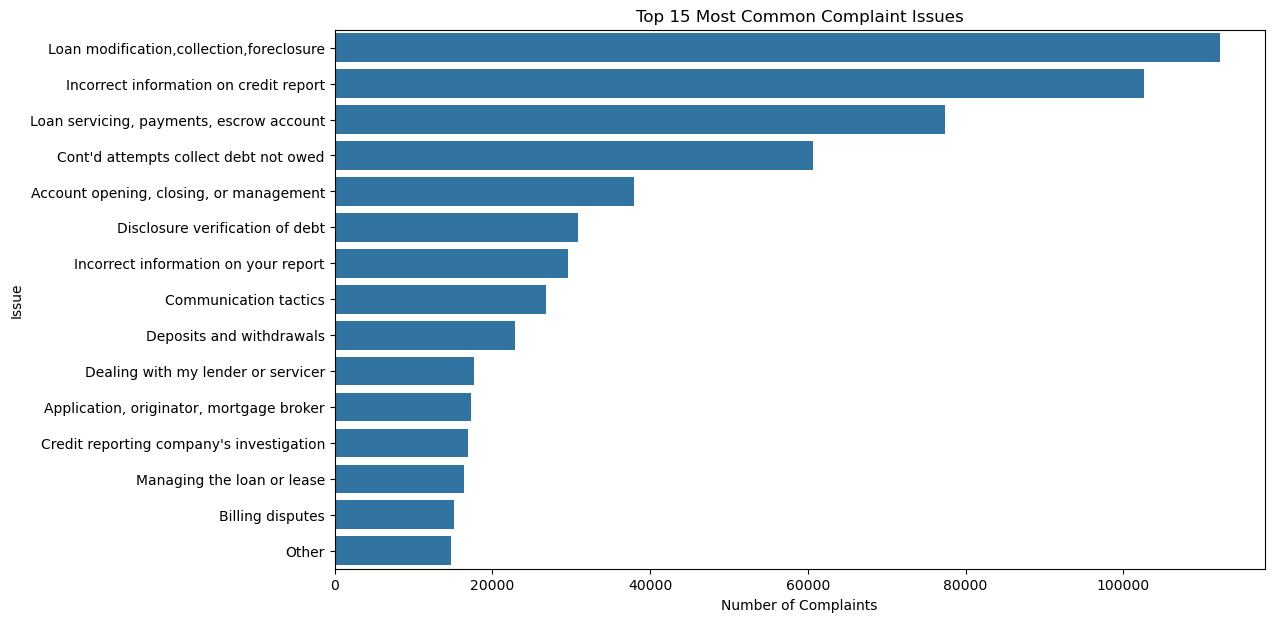

In [13]:
# Display the 15 most common complaint issues
top_issues = df["Issue"].value_counts().head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_issues.values,
    y=top_issues.index
)

plt.title("Top 15 Most Common Complaint Issues")
plt.xlabel("Number of Complaints")
plt.ylabel("Issue")
plt.show()

In [14]:
# Count complaints by submission method
df["Submitted via"].value_counts()

Submitted via
Web            634850
Referral       142931
Phone           58505
Postal mail     55066
Fax             12277
Email             354
Name: count, dtype: int64

> **Observation:** Most complaints were submitted through the web, followed by referrals and phone submissions. Email was the least common submission method in the dataset.

In [15]:
# Count complaints by timely response status
df["Timely response?"].value_counts()

Timely response?
Yes    879376
No      24607
Name: count, dtype: int64

> **Observation:** Most complaints received a timely response, while a much smaller number of complaints did not.

In [16]:
# Calculate the number of words in each complaint narrative
text_word_counts = df["Consumer complaint narrative"].dropna().str.split().str.len()

text_word_counts.describe()

count    199970.000000
mean        192.073456
std         178.040052
min           1.000000
25%          72.000000
50%         136.000000
75%         253.000000
max        6314.000000
Name: Consumer complaint narrative, dtype: float64

> **Observation:** The complaint narratives vary considerably in length. Most complaints are relatively short, while a smaller number contain very long descriptions. This variation will be considered during text preprocessing.

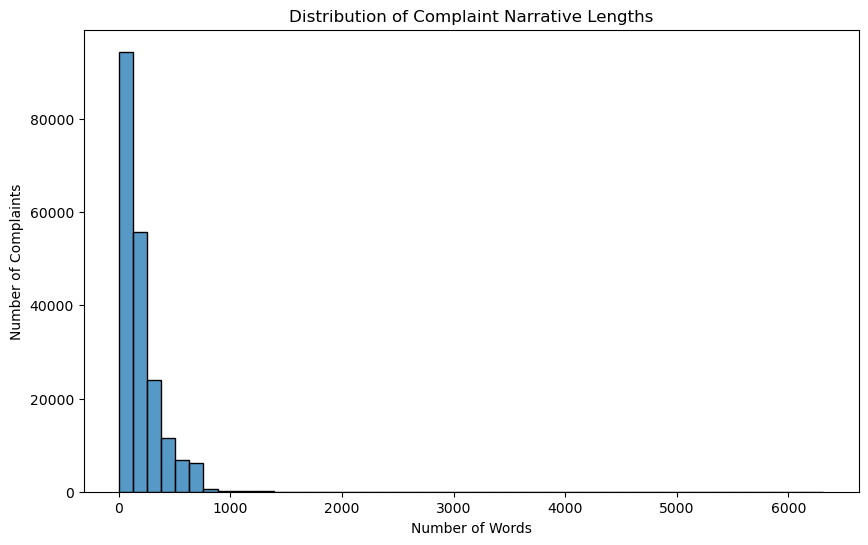

In [17]:
# Plot the distribution of complaint narrative lengths
plt.figure(figsize=(10, 6))

sns.histplot(text_word_counts, bins=50)

plt.title("Distribution of Complaint Narrative Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Complaints")
plt.show()

In [18]:
# Count complaints with fewer than 5 words
(text_word_counts < 5).sum()

np.int64(168)

> **Observation:** Only 168 complaint narratives contain fewer than five words. Since these very short texts provide limited information for text classification, they will be considered during the cleaning stage.

In [19]:
# Count duplicated complaint narratives
df["Consumer complaint narrative"].dropna().duplicated().sum()

np.int64(4653)

> **Observation:** The dataset contains 4,653 repeated complaint narratives. Although the complete rows are not duplicated, some complaint texts appear more than once. These duplicates will be considered during data preparation to avoid data leakage between the training and test sets.

In [20]:
# Display the most frequently repeated complaint narratives
df["Consumer complaint narrative"].value_counts().head(5)

Consumer complaint narrative
I am filing this complaint because Experian has ignored my request to provide me with the documents that their company has on file that was used to verify the accounts I disputed. Being that they have gone past the 30 day mark and can not verify these accounts, under Section 611 ( 5 ) ( A ) of the FCRA - they are required to " ... promptly delete all information which can not be verified '' that I have disputed. Please resolve this manner as soon as possible. Thank you.                                                                       103
I am filing this complaint because TransUnion has ignored my request to provide me with the documents that their company has on file that was used to verify the accounts I disputed. Being that they have gone past the 30 day mark and can not verify these accounts, under Section 611 ( 5 ) ( A ) of the FCRA - they are required to " ... promptly delete all information which can not be verified '' that I have disputed. Plea

> **Observation:** Some complaint narratives are repeated across multiple records, often with minor changes such as the company name. These repetitions may represent recurring complaint patterns rather than accidental duplicate records, so they will not be removed blindly.

In [21]:
# Count records with both complaint narratives and product labels
df[["Consumer complaint narrative", "Product"]].dropna().shape

(199970, 2)

In [22]:
# Create a separate dataset for text classification
nlp_df = df[["Consumer complaint narrative", "Product"]].dropna().copy()

nlp_df.head()

,Consumer complaint narrative,Product
1,I have outdated information on my credit repor...,Credit reporting
2,I purchased a new car on XXXX XXXX. The car de...,Consumer Loan
7,An account on my credit report has a mistaken ...,Credit reporting
12,This company refuses to provide me verificatio...,Debt collection
16,This complaint is in regards to Square Two Fin...,Debt collection


In [23]:
# Check the structure of the NLP dataset
nlp_df.info()

<class 'pandas.DataFrame'>
Index: 199970 entries, 1 to 903982
Data columns (total 2 columns):
 #   Column                        Non-Null Count   Dtype
---  ------                        --------------   -----
 0   Consumer complaint narrative  199970 non-null  str  
 1   Product                       199970 non-null  str  
dtypes: str(2)
memory usage: 208.4 MB


In [24]:
# Reset the index after filtering the dataset
nlp_df = nlp_df.reset_index(drop=True)

nlp_df.head()

,Consumer complaint narrative,Product
0,I have outdated information on my credit repor...,Credit reporting
1,I purchased a new car on XXXX XXXX. The car de...,Consumer Loan
2,An account on my credit report has a mistaken ...,Credit reporting
3,This company refuses to provide me verificatio...,Debt collection
4,This complaint is in regards to Square Two Fin...,Debt collection


In [25]:
# Check for empty or whitespace-only complaint narratives
empty_text = nlp_df["Consumer complaint narrative"].str.strip().eq("").sum()

empty_text

np.int64(0)

> **Observation:** No empty or whitespace-only complaint narratives were found in the NLP dataset.

In [26]:
# Check the data type of complaint narratives
nlp_df["Consumer complaint narrative"].map(type).value_counts()

Consumer complaint narrative
<class 'str'>    199970
Name: count, dtype: int64

> **Observation:** All complaint narratives are stored as text strings, so no data type conversion is required for the text column.

In [27]:
# Check for newlines and repeated whitespace in complaint narratives
has_newlines = nlp_df["Consumer complaint narrative"].str.contains(r"\n", regex=True).sum()
has_extra_spaces = nlp_df["Consumer complaint narrative"].str.contains(r"\s{2,}", regex=True).sum()

print("Narratives containing newlines:", has_newlines)
print("Narratives containing repeated whitespace:", has_extra_spaces)

Narratives containing newlines: 52397
Narratives containing repeated whitespace: 70069


> **Observation:** Many complaint narratives contain newline characters and repeated whitespace. These formatting differences do not add useful information for text classification, so they will be normalized during text cleaning.

## Data Cleaning

In [28]:
# Normalize whitespace in complaint narratives
nlp_df["clean_text"] = (
    nlp_df["Consumer complaint narrative"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

nlp_df[["Consumer complaint narrative", "clean_text"]].head()

,Consumer complaint narrative,clean_text
0,I have outdated information on my credit repor...,I have outdated information on my credit repor...
1,I purchased a new car on XXXX XXXX. The car de...,I purchased a new car on XXXX XXXX. The car de...
2,An account on my credit report has a mistaken ...,An account on my credit report has a mistaken ...
3,This company refuses to provide me verificatio...,This company refuses to provide me verificatio...
4,This complaint is in regards to Square Two Fin...,This complaint is in regards to Square Two Fin...


In [29]:
# Convert complaint text to lowercase
nlp_df["clean_text"] = nlp_df["clean_text"].str.lower()

nlp_df[["Consumer complaint narrative", "clean_text"]].head()

,Consumer complaint narrative,clean_text
0,I have outdated information on my credit repor...,i have outdated information on my credit repor...
1,I purchased a new car on XXXX XXXX. The car de...,i purchased a new car on xxxx xxxx. the car de...
2,An account on my credit report has a mistaken ...,an account on my credit report has a mistaken ...
3,This company refuses to provide me verificatio...,this company refuses to provide me verificatio...
4,This complaint is in regards to Square Two Fin...,this complaint is in regards to square two fin...


In [30]:
# Remove very short complaint narratives
before = len(nlp_df)

nlp_df = nlp_df[nlp_df["clean_text"].str.split().str.len() >= 5].copy()

after = len(nlp_df)

print(f"Rows removed: {before - after}")
print(f"Remaining rows: {after}")

Rows removed: 168
Remaining rows: 199802


> **Observation:** Very short complaint narratives were removed because they contain limited information for text classification. The dataset now contains 199,802 complaint narratives.

In [31]:
# Remove URLs from complaint narratives
nlp_df["clean_text"] = (
    nlp_df["clean_text"]
    .str.replace(r"https?://\S+|www\.\S+", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

nlp_df["clean_text"].head()

0    i have outdated information on my credit repor...
1    i purchased a new car on xxxx xxxx. the car de...
2    an account on my credit report has a mistaken ...
3    this company refuses to provide me verificatio...
4    this complaint is in regards to square two fin...
Name: clean_text, dtype: str

In [32]:
# Remove punctuation and special characters
nlp_df["clean_text"] = (
    nlp_df["clean_text"]
    .str.replace(r"[^a-z0-9\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

nlp_df["clean_text"].head()

0    i have outdated information on my credit repor...
1    i purchased a new car on xxxx xxxx the car dea...
2    an account on my credit report has a mistaken ...
3    this company refuses to provide me verificatio...
4    this complaint is in regards to square two fin...
Name: clean_text, dtype: str

> **Observation:** The target classes remain highly imbalanced after text cleaning. Debt collection, Mortgage, and Credit reporting contain the largest number of complaints, while several categories have relatively few samples. This imbalance will be considered during model training and evaluation.

In [33]:
# Check repeated complaint texts and label consistency
text_counts = nlp_df["clean_text"].value_counts()

repeated_texts = text_counts[text_counts > 1].index
repeated_df = nlp_df[nlp_df["clean_text"].isin(repeated_texts)]

label_counts = repeated_df.groupby("clean_text")["Product"].nunique()

consistent_repeated = label_counts[label_counts == 1]
conflicting_repeated = label_counts[label_counts > 1]

print(f"Repeated unique texts: {len(repeated_texts)}")
print(f"Repeated texts with consistent labels: {len(consistent_repeated)}")
print(f"Repeated texts with conflicting labels: {len(conflicting_repeated)}")

Repeated unique texts: 3225
Repeated texts with consistent labels: 3132
Repeated texts with conflicting labels: 93


> **Observation:**  
> The dataset contains 3,225 repeated complaint texts. Most repeated texts (3,132) have consistent product labels, while 93 repeated texts have conflicting labels. The conflicting cases require further inspection before deciding how to handle them.

In [34]:
# Count rows affected by texts with conflicting labels
conflicting_rows = nlp_df[nlp_df["clean_text"].isin(conflicting_repeated.index)]

print(f"Rows with conflicting labels: {len(conflicting_rows)}")

Rows with conflicting labels: 317


> **Observation:**  
> The 93 conflicting texts affect 317 rows. These cases are relatively limited compared with the full dataset, but they need to be inspected before deciding how to handle them.

In [35]:
# Inspect examples of texts with conflicting product labels
conflicting_examples = (
    conflicting_rows.groupby("clean_text")["Product"]
    .apply(list)
    .head(10)
)

for text, labels in conflicting_examples.items():
    print(f"Labels: {labels}")
    print(f"Text: {text[:300]}...")
    print("-" * 80)

Labels: ['Debt collection', 'Debt collection', 'Debt collection', 'Debt collection', 'Debt collection', 'Payday loan', 'Debt collection']
Text: account was paid as agreed...
--------------------------------------------------------------------------------
Labels: ['Credit reporting', 'Debt collection', 'Credit reporting']
Text: after applying for credit several months ago i was denied and requested my free credit reports from all xxxx cra s it showed i had an account from a xxxx after several days and hours of getting to the bottom of this it shows that the account was opened when i was xxxx years old i submitted my driver...
--------------------------------------------------------------------------------
Labels: ['Debt collection', 'Mortgage']
Text: after the past several years of xxxx starting at the height of the subprime mortgage crisis my wife and i have been through hell with our property in xxxx everything from a neighborhood turning into a criminal wasteland because of everyone 

> **Observation:**  
> The conflicting labels often occur in complaints that discuss multiple related financial issues, such as debt collection and credit reporting. Therefore, these records were retained rather than removed, as the conflicting labels may reflect the nature of the original complaint categorization.

In [36]:
# Count duplicate rows with identical text and product label
duplicate_rows = nlp_df.duplicated(
    subset=["clean_text", "Product"],
    keep="first"
)

print(f"Duplicate rows with identical text and label: {duplicate_rows.sum()}")

Duplicate rows with identical text and label: 5148


In [37]:
# Remove exact duplicate complaint texts with the same product label
before = len(nlp_df)

nlp_df = nlp_df.drop_duplicates(
    subset=["clean_text", "Product"],
    keep="first"
).reset_index(drop=True)

print(f"Rows before removing duplicates: {before}")
print(f"Rows after removing duplicates: {len(nlp_df)}")
print(f"Rows removed: {before - len(nlp_df)}")

Rows before removing duplicates: 199802
Rows after removing duplicates: 194654
Rows removed: 5148


> **Observation:**  
> After removing exact duplicate complaint texts with the same product label, the dataset was reduced from 199,802 to 194,654 rows. This removes redundant records while preserving complaints that have different product labels.

In [38]:
# Check whether identical complaint texts still have multiple labels
remaining_text_counts = nlp_df.groupby("clean_text")["Product"].nunique()

remaining_conflicts = remaining_text_counts[remaining_text_counts > 1]

print(f"Texts with conflicting labels: {len(remaining_conflicts)}")
print(f"Rows affected by conflicting labels: {nlp_df[nlp_df['clean_text'].isin(remaining_conflicts.index)].shape[0]}")

Texts with conflicting labels: 93
Rows affected by conflicting labels: 196


> **Observation:**  
> After removing exact duplicate text-label pairs, 93 complaint texts still have conflicting product labels, affecting 196 rows. These records were retained because the conflicts can occur when a complaint involves multiple related financial issues.

In [39]:
# Check for empty texts after cleaning
empty_texts = nlp_df["clean_text"].str.strip().eq("").sum()

print(f"Empty texts: {empty_texts}")

Empty texts: 0


In [40]:
# Check target class distribution after cleaning
nlp_df["Product"].value_counts()

Product
Debt collection                                                                 46619
Mortgage                                                                        36545
Credit reporting                                                                29677
Credit card                                                                     18744
Bank account or service                                                         14850
Student loan                                                                    13273
Credit reporting, credit repair services, or other personal consumer reports    12845
Consumer Loan                                                                    9435
Credit card or prepaid card                                                      3344
Checking or savings account                                                      2135
Payday loan                                                                      1742
Money transfers                               

In [41]:
# Check the final number of product categories
print(f"Number of categories: {nlp_df['Product'].nunique()}")

Number of categories: 18


## Data Splitting

In [42]:
# Define text features and target labels
X = nlp_df["clean_text"]
y = nlp_df["Product"]

print(f"Features: {X.shape}")
print(f"Target: {y.shape}")

Features: (194654,)
Target: (194654,)


In [43]:
# Create a stratified split while keeping identical texts in the same set
X = nlp_df["clean_text"]
y = nlp_df["Product"]
groups = nlp_df["clean_text"]

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, test_idx = next(sgkf.split(X, y, groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Training ratio: {len(X_train) / len(X):.2%}")
print(f"Testing ratio: {len(X_test) / len(X):.2%}")

# Verify that no identical text appears in both sets
overlap = set(X_train).intersection(set(X_test))

print(f"Overlapping texts: {len(overlap)}")

Training samples: 155723
Testing samples: 38931
Training ratio: 80.00%
Testing ratio: 20.00%
Overlapping texts: 0


> **Observation:**  
> The dataset was split into 80% training and 20% testing data using a stratified group split. Identical complaint texts were kept within the same set, resulting in zero text overlap between training and testing data.

## TF-IDF Feature Extraction

In [44]:
# Extract TF-IDF features using word n-grams and sublinear term frequency

tfidf = TfidfVectorizer(
    max_features=100000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Training TF-IDF shape: {X_train_tfidf.shape}")
print(f"Testing TF-IDF shape: {X_test_tfidf.shape}")

Training TF-IDF shape: (155723, 100000)
Testing TF-IDF shape: (38931, 100000)


> **Observation:**  
> TF-IDF transformed the training and testing data into 100,000 sparse features using word unigrams and bigrams. The vectorizer was fitted only on the training data to prevent data leakage.

## Models Used

Three classification algorithms will be trained and compared:

- **Logistic Regression:** A strong and interpretable baseline for text classification with TF-IDF features.
- **Multinomial Naive Bayes:** A lightweight probabilistic model commonly used for text classification.
- **Linear SVM:** A strong classifier for high-dimensional sparse text data such as TF-IDF.

The models will be evaluated using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

### Hyperparameter Selection

The main hyperparameters of the three classification models were selected to improve performance on the imbalanced product categories:

- **Logistic Regression:** `C = 2.0` with balanced class weights.
- **Multinomial Naive Bayes:** `alpha = 0.01`.
- **Linear SVM:** `C = 0.5` with balanced class weights.

The selection was based on macro F1-score, which gives equal importance to minority and majority classes and is therefore more appropriate for this imbalanced classification problem.

### Model Training 1

In [45]:
# Train Logistic Regression

logreg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    C=2.0,
    random_state=42
)

logreg.fit(X_train_tfidf, y_train)

y_pred_logreg = logreg.predict(X_test_tfidf)

print(f"Predictions generated: {len(y_pred_logreg)}")

Predictions generated: 38931


### Model Evaluation 1

Training Performance:
Accuracy:           0.8872
Weighted Precision: 0.8915
Weighted Recall:    0.8872
Weighted F1:        0.8878
Macro Precision:    0.8501
Macro Recall:       0.9455
Macro F1:           0.8915

Testing Performance:
Accuracy:           0.7898
Weighted Precision: 0.7959
Weighted Recall:    0.7898
Weighted F1:        0.7917
Macro Precision:    0.5567
Macro Recall:       0.5781
Macro F1:           0.5618


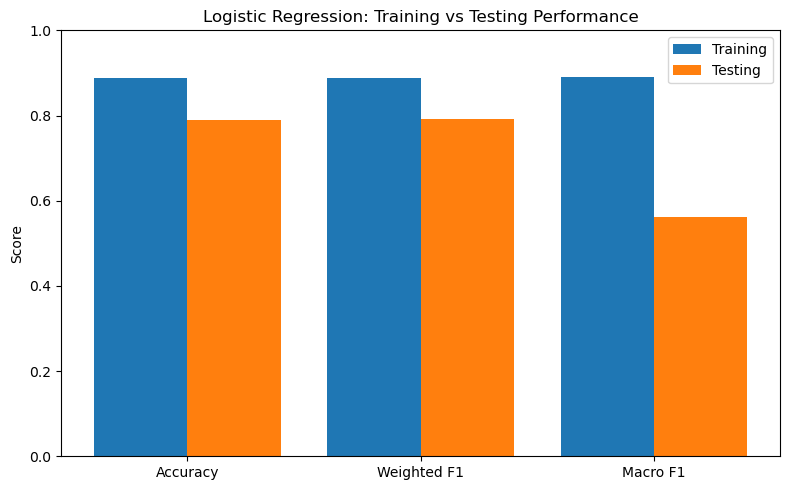

In [46]:
# Generate predictions for training and testing data

y_train_pred_logreg = logreg.predict(X_train_tfidf)
y_test_pred_logreg = y_pred_logreg

# Calculate all training metrics
train_accuracy = accuracy_score(y_train, y_train_pred_logreg)

train_precision_weighted = precision_score(
    y_train, y_train_pred_logreg, average="weighted", zero_division=0
)
train_recall_weighted = recall_score(
    y_train, y_train_pred_logreg, average="weighted", zero_division=0
)
train_f1_weighted = f1_score(
    y_train, y_train_pred_logreg, average="weighted", zero_division=0
)

train_precision_macro = precision_score(
    y_train, y_train_pred_logreg, average="macro", zero_division=0
)
train_recall_macro = recall_score(
    y_train, y_train_pred_logreg, average="macro", zero_division=0
)
train_f1_macro = f1_score(
    y_train, y_train_pred_logreg, average="macro", zero_division=0
)

# Calculate all testing metrics
test_accuracy = accuracy_score(y_test, y_test_pred_logreg)

test_precision_weighted = precision_score(
    y_test, y_test_pred_logreg, average="weighted", zero_division=0
)
test_recall_weighted = recall_score(
    y_test, y_test_pred_logreg, average="weighted", zero_division=0
)
test_f1_weighted = f1_score(
    y_test, y_test_pred_logreg, average="weighted", zero_division=0
)

test_precision_macro = precision_score(
    y_test, y_test_pred_logreg, average="macro", zero_division=0
)
test_recall_macro = recall_score(
    y_test, y_test_pred_logreg, average="macro", zero_division=0
)
test_f1_macro = f1_score(
    y_test, y_test_pred_logreg, average="macro", zero_division=0
)

print("Training Performance:")
print(f"Accuracy:           {train_accuracy:.4f}")
print(f"Weighted Precision: {train_precision_weighted:.4f}")
print(f"Weighted Recall:    {train_recall_weighted:.4f}")
print(f"Weighted F1:        {train_f1_weighted:.4f}")
print(f"Macro Precision:    {train_precision_macro:.4f}")
print(f"Macro Recall:       {train_recall_macro:.4f}")
print(f"Macro F1:           {train_f1_macro:.4f}")

print("\nTesting Performance:")
print(f"Accuracy:           {test_accuracy:.4f}")
print(f"Weighted Precision: {test_precision_weighted:.4f}")
print(f"Weighted Recall:    {test_recall_weighted:.4f}")
print(f"Weighted F1:        {test_f1_weighted:.4f}")
print(f"Macro Precision:    {test_precision_macro:.4f}")
print(f"Macro Recall:       {test_recall_macro:.4f}")
print(f"Macro F1:           {test_f1_macro:.4f}")

# Plot the main metrics for training vs testing
metrics = ["Accuracy", "Weighted F1", "Macro F1"]

train_values = [
    train_accuracy,
    train_f1_weighted,
    train_f1_macro
]

test_values = [
    test_accuracy,
    test_f1_weighted,
    test_f1_macro
]

x = range(len(metrics))

plt.figure(figsize=(8, 5))
plt.bar([i - 0.2 for i in x], train_values, width=0.4, label="Training")
plt.bar([i + 0.2 for i in x], test_values, width=0.4, label="Testing")

plt.xticks(list(x), metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Logistic Regression: Training vs Testing Performance")
plt.legend()
plt.tight_layout()
plt.show()

> **Observation:**  
> Logistic Regression achieved 0.7898 accuracy and a weighted F1-score of 0.7917 on the testing data. The Macro F1-score was lower at 0.5618, indicating weaker performance across minority classes. The gap between training and testing performance, particularly in Macro F1, suggests some overfitting and reduced generalization to less frequent product categories.

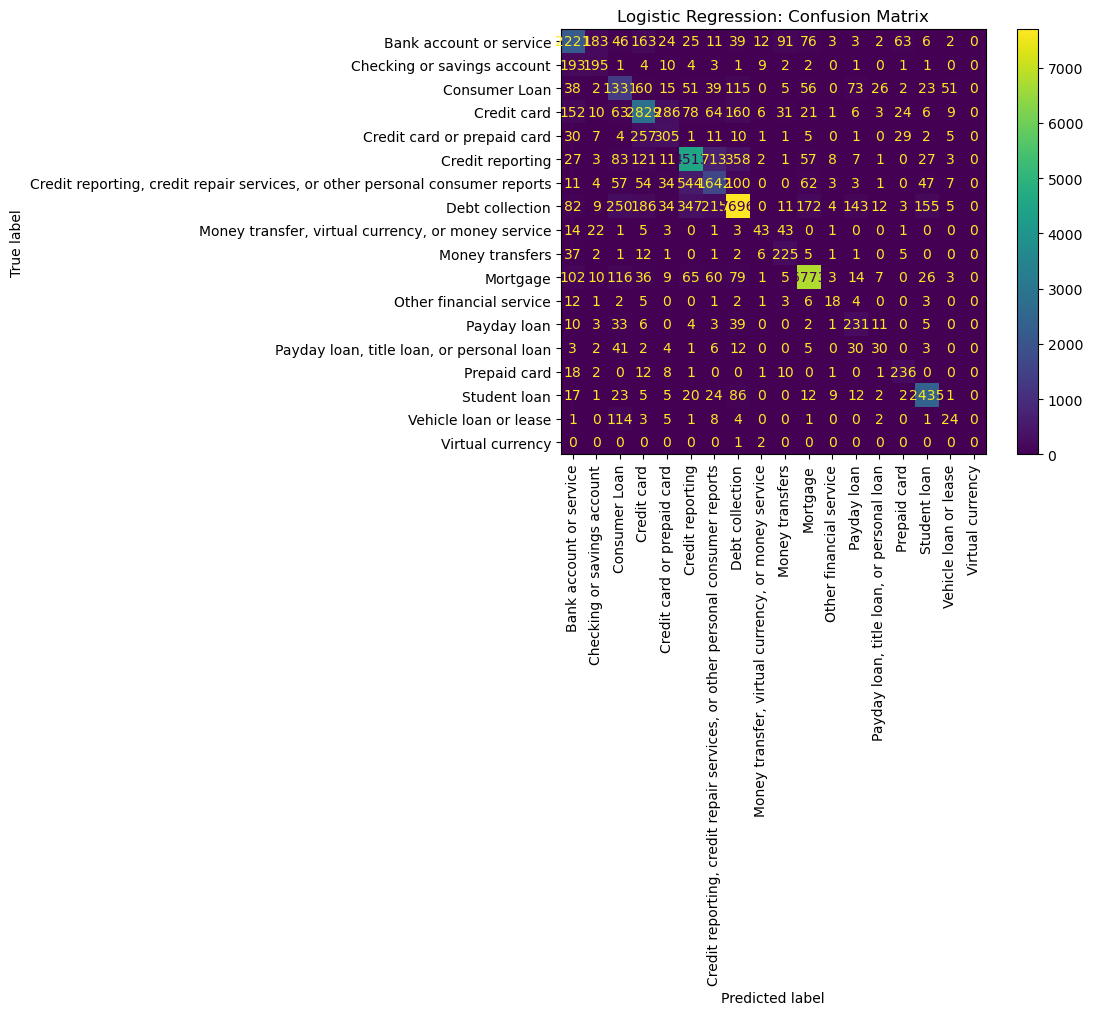

In [47]:
# Plot the confusion matrix for Logistic Regression
fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_logreg,
    xticks_rotation="vertical",
    values_format="d",
    ax=ax
)

ax.set_title("Logistic Regression: Confusion Matrix")
plt.tight_layout()
plt.show()

> **Observation:**  
> The confusion matrix shows strong predictions for several major product categories, including Debt collection, Mortgage, and Credit reporting. However, noticeable confusion remains between related financial categories, while minority classes show more scattered predictions. This reflects the lower Macro F1-score compared with the weighted F1-score.

### Model Training 2

In [48]:
# Train Multinomial Naive Bayes

nb_model = MultinomialNB(alpha=0.01)
nb_model.fit(X_train_tfidf, y_train)

# Generate predictions for training and testing data
y_train_pred_nb = nb_model.predict(X_train_tfidf)
y_test_pred_nb = nb_model.predict(X_test_tfidf)

print(f"Training predictions: {len(y_train_pred_nb)}")
print(f"Testing predictions: {len(y_test_pred_nb)}")

Training predictions: 155723
Testing predictions: 38931


### Model Evaluation 2

Training Performance:
Accuracy:           0.8583
Weighted Precision: 0.8603
Weighted Recall:    0.8583
Weighted F1:        0.8563
Macro Precision:    0.9145
Macro Recall:       0.8494
Macro F1:           0.8774

Testing Performance:
Accuracy:           0.7678
Weighted Precision: 0.7644
Weighted Recall:    0.7678
Weighted F1:        0.7494
Macro Precision:    0.6802
Macro Recall:       0.4181
Macro F1:           0.4440


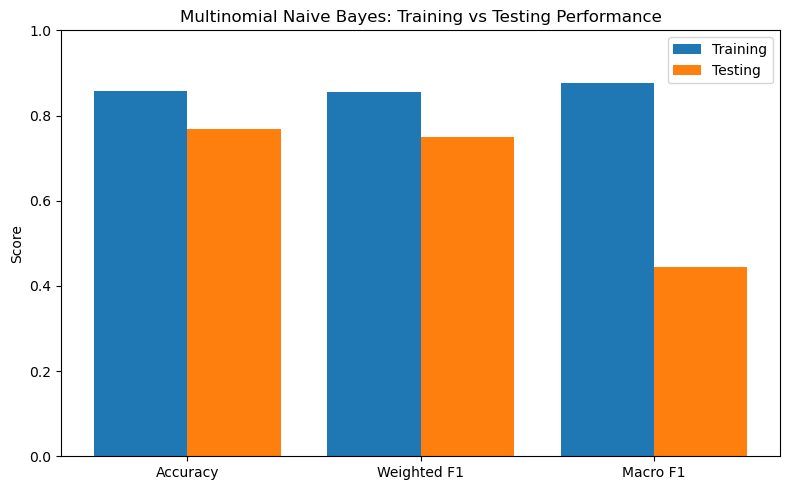

In [49]:
# Calculate all training metrics

train_accuracy_nb = accuracy_score(y_train, y_train_pred_nb)

train_precision_weighted_nb = precision_score(
    y_train, y_train_pred_nb, average="weighted", zero_division=0
)
train_recall_weighted_nb = recall_score(
    y_train, y_train_pred_nb, average="weighted", zero_division=0
)
train_f1_weighted_nb = f1_score(
    y_train, y_train_pred_nb, average="weighted", zero_division=0
)

train_precision_macro_nb = precision_score(
    y_train, y_train_pred_nb, average="macro", zero_division=0
)
train_recall_macro_nb = recall_score(
    y_train, y_train_pred_nb, average="macro", zero_division=0
)
train_f1_macro_nb = f1_score(
    y_train, y_train_pred_nb, average="macro", zero_division=0
)

# Calculate all testing metrics
test_accuracy_nb = accuracy_score(y_test, y_test_pred_nb)

test_precision_weighted_nb = precision_score(
    y_test, y_test_pred_nb, average="weighted", zero_division=0
)
test_recall_weighted_nb = recall_score(
    y_test, y_test_pred_nb, average="weighted", zero_division=0
)
test_f1_weighted_nb = f1_score(
    y_test, y_test_pred_nb, average="weighted", zero_division=0
)

test_precision_macro_nb = precision_score(
    y_test, y_test_pred_nb, average="macro", zero_division=0
)
test_recall_macro_nb = recall_score(
    y_test, y_test_pred_nb, average="macro", zero_division=0
)
test_f1_macro_nb = f1_score(
    y_test, y_test_pred_nb, average="macro", zero_division=0
)

print("Training Performance:")
print(f"Accuracy:           {train_accuracy_nb:.4f}")
print(f"Weighted Precision: {train_precision_weighted_nb:.4f}")
print(f"Weighted Recall:    {train_recall_weighted_nb:.4f}")
print(f"Weighted F1:        {train_f1_weighted_nb:.4f}")
print(f"Macro Precision:    {train_precision_macro_nb:.4f}")
print(f"Macro Recall:       {train_recall_macro_nb:.4f}")
print(f"Macro F1:           {train_f1_macro_nb:.4f}")

print("\nTesting Performance:")
print(f"Accuracy:           {test_accuracy_nb:.4f}")
print(f"Weighted Precision: {test_precision_weighted_nb:.4f}")
print(f"Weighted Recall:    {test_recall_weighted_nb:.4f}")
print(f"Weighted F1:        {test_f1_weighted_nb:.4f}")
print(f"Macro Precision:    {test_precision_macro_nb:.4f}")
print(f"Macro Recall:       {test_recall_macro_nb:.4f}")
print(f"Macro F1:           {test_f1_macro_nb:.4f}")

# Plot the main metrics for training vs testing
metrics = ["Accuracy", "Weighted F1", "Macro F1"]

train_values = [
    train_accuracy_nb,
    train_f1_weighted_nb,
    train_f1_macro_nb
]

test_values = [
    test_accuracy_nb,
    test_f1_weighted_nb,
    test_f1_macro_nb
]

x = range(len(metrics))

plt.figure(figsize=(8, 5))
plt.bar([i - 0.2 for i in x], train_values, width=0.4, label="Training")
plt.bar([i + 0.2 for i in x], test_values, width=0.4, label="Testing")

plt.xticks(list(x), metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Multinomial Naive Bayes: Training vs Testing Performance")
plt.legend()
plt.tight_layout()
plt.show()

> **Observation:**  
> Multinomial Naive Bayes achieved 0.7678 accuracy and a weighted F1-score of 0.7494 on the testing data. The Macro F1-score was 0.4440, indicating weaker performance across minority classes. The noticeable gap between training and testing performance, especially in Macro F1, suggests overfitting and limited generalization across less frequent product categories.

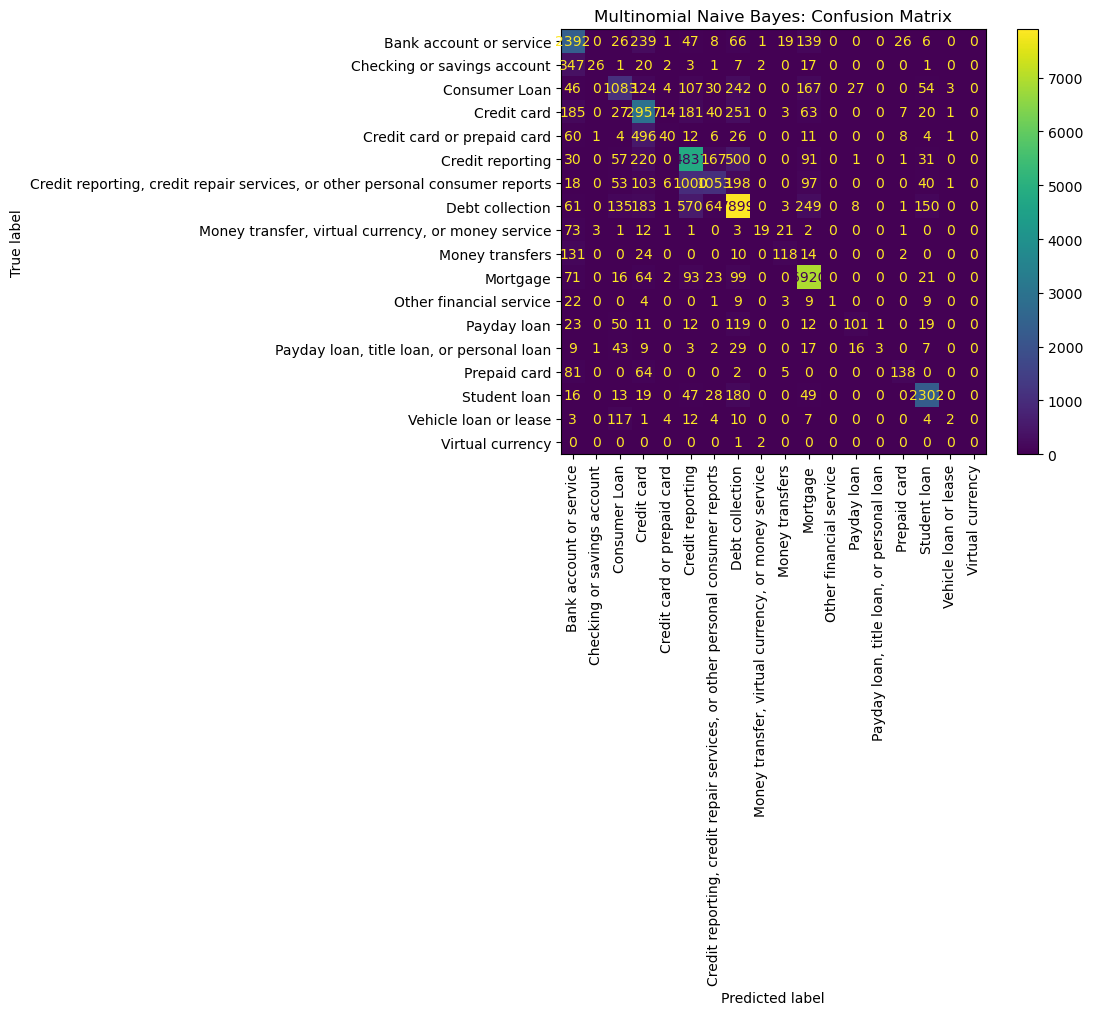

In [50]:
# Plot the confusion matrix for Multinomial Naive Bayes

fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_nb,
    xticks_rotation="vertical",
    values_format="d",
    ax=ax
)

ax.set_title("Multinomial Naive Bayes: Confusion Matrix")
plt.tight_layout()
plt.show()

> **Observation:**  
> The confusion matrix shows stronger predictions for several major product categories, while noticeable confusion remains between related financial categories. Minority classes have more scattered predictions and are more frequently confused with larger categories. This contributes to the lower Macro F1-score compared with the weighted F1-score.

### Model Training 3

In [51]:
# Train Linear SVM with balanced class weights

svm_model = LinearSVC(
    C=0.5,
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

# Generate predictions for training and testing data
y_train_pred_svm = svm_model.predict(X_train_tfidf)
y_test_pred_svm = svm_model.predict(X_test_tfidf)

print(f"Training predictions: {len(y_train_pred_svm)}")
print(f"Testing predictions: {len(y_test_pred_svm)}")

Training predictions: 155723
Testing predictions: 38931


### Model Evaluation 3

Training Performance:
Accuracy:           0.9448
Weighted Precision: 0.9448
Weighted Recall:    0.9448
Weighted F1:        0.9446
Macro Precision:    0.9462
Macro Recall:       0.9710
Macro F1:           0.9580

Testing Performance:
Accuracy:           0.8114
Weighted Precision: 0.8054
Weighted Recall:    0.8114
Weighted F1:        0.8067
Macro Precision:    0.5896
Macro Recall:       0.5456
Macro F1:           0.5526


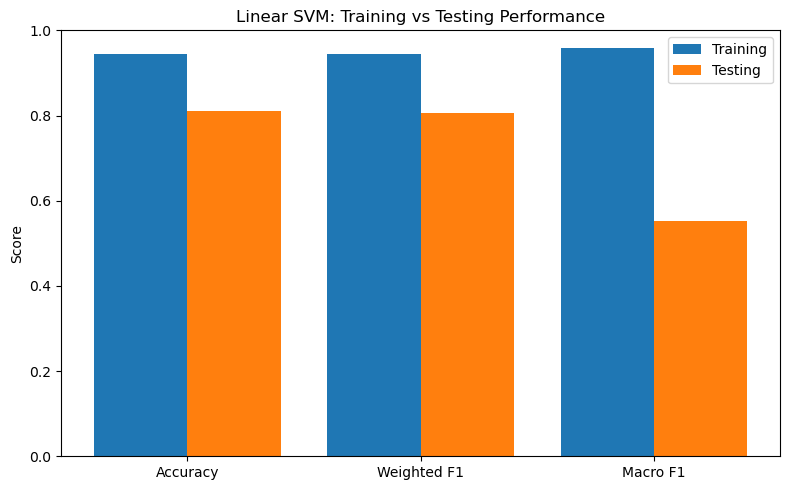

In [52]:
# Calculate all training metrics

train_accuracy_svm = accuracy_score(y_train, y_train_pred_svm)

train_precision_weighted_svm = precision_score(
    y_train, y_train_pred_svm, average="weighted", zero_division=0
)
train_recall_weighted_svm = recall_score(
    y_train, y_train_pred_svm, average="weighted", zero_division=0
)
train_f1_weighted_svm = f1_score(
    y_train, y_train_pred_svm, average="weighted", zero_division=0
)

train_precision_macro_svm = precision_score(
    y_train, y_train_pred_svm, average="macro", zero_division=0
)
train_recall_macro_svm = recall_score(
    y_train, y_train_pred_svm, average="macro", zero_division=0
)
train_f1_macro_svm = f1_score(
    y_train, y_train_pred_svm, average="macro", zero_division=0
)

# Calculate all testing metrics
test_accuracy_svm = accuracy_score(y_test, y_test_pred_svm)

test_precision_weighted_svm = precision_score(
    y_test, y_test_pred_svm, average="weighted", zero_division=0
)
test_recall_weighted_svm = recall_score(
    y_test, y_test_pred_svm, average="weighted", zero_division=0
)
test_f1_weighted_svm = f1_score(
    y_test, y_test_pred_svm, average="weighted", zero_division=0
)

test_precision_macro_svm = precision_score(
    y_test, y_test_pred_svm, average="macro", zero_division=0
)
test_recall_macro_svm = recall_score(
    y_test, y_test_pred_svm, average="macro", zero_division=0
)
test_f1_macro_svm = f1_score(
    y_test, y_test_pred_svm, average="macro", zero_division=0
)

print("Training Performance:")
print(f"Accuracy:           {train_accuracy_svm:.4f}")
print(f"Weighted Precision: {train_precision_weighted_svm:.4f}")
print(f"Weighted Recall:    {train_recall_weighted_svm:.4f}")
print(f"Weighted F1:        {train_f1_weighted_svm:.4f}")
print(f"Macro Precision:    {train_precision_macro_svm:.4f}")
print(f"Macro Recall:       {train_recall_macro_svm:.4f}")
print(f"Macro F1:           {train_f1_macro_svm:.4f}")

print("\nTesting Performance:")
print(f"Accuracy:           {test_accuracy_svm:.4f}")
print(f"Weighted Precision: {test_precision_weighted_svm:.4f}")
print(f"Weighted Recall:    {test_recall_weighted_svm:.4f}")
print(f"Weighted F1:        {test_f1_weighted_svm:.4f}")
print(f"Macro Precision:    {test_precision_macro_svm:.4f}")
print(f"Macro Recall:       {test_recall_macro_svm:.4f}")
print(f"Macro F1:           {test_f1_macro_svm:.4f}")

# Plot the main metrics for training vs testing
metrics = ["Accuracy", "Weighted F1", "Macro F1"]

train_values = [
    train_accuracy_svm,
    train_f1_weighted_svm,
    train_f1_macro_svm
]

test_values = [
    test_accuracy_svm,
    test_f1_weighted_svm,
    test_f1_macro_svm
]

x = range(len(metrics))

plt.figure(figsize=(8, 5))
plt.bar([i - 0.2 for i in x], train_values, width=0.4, label="Training")
plt.bar([i + 0.2 for i in x], test_values, width=0.4, label="Testing")

plt.xticks(list(x), metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Linear SVM: Training vs Testing Performance")
plt.legend()
plt.tight_layout()
plt.show()

> **Observation:**  
> Linear SVM achieved 0.8114 accuracy and a weighted F1-score of 0.8067 on the testing data, showing strong overall classification performance. The Macro F1-score was 0.5526, indicating that performance is weaker across minority classes. The noticeable gap between training and testing performance, particularly in Macro F1, suggests some overfitting and limited generalization to less frequent product categories.

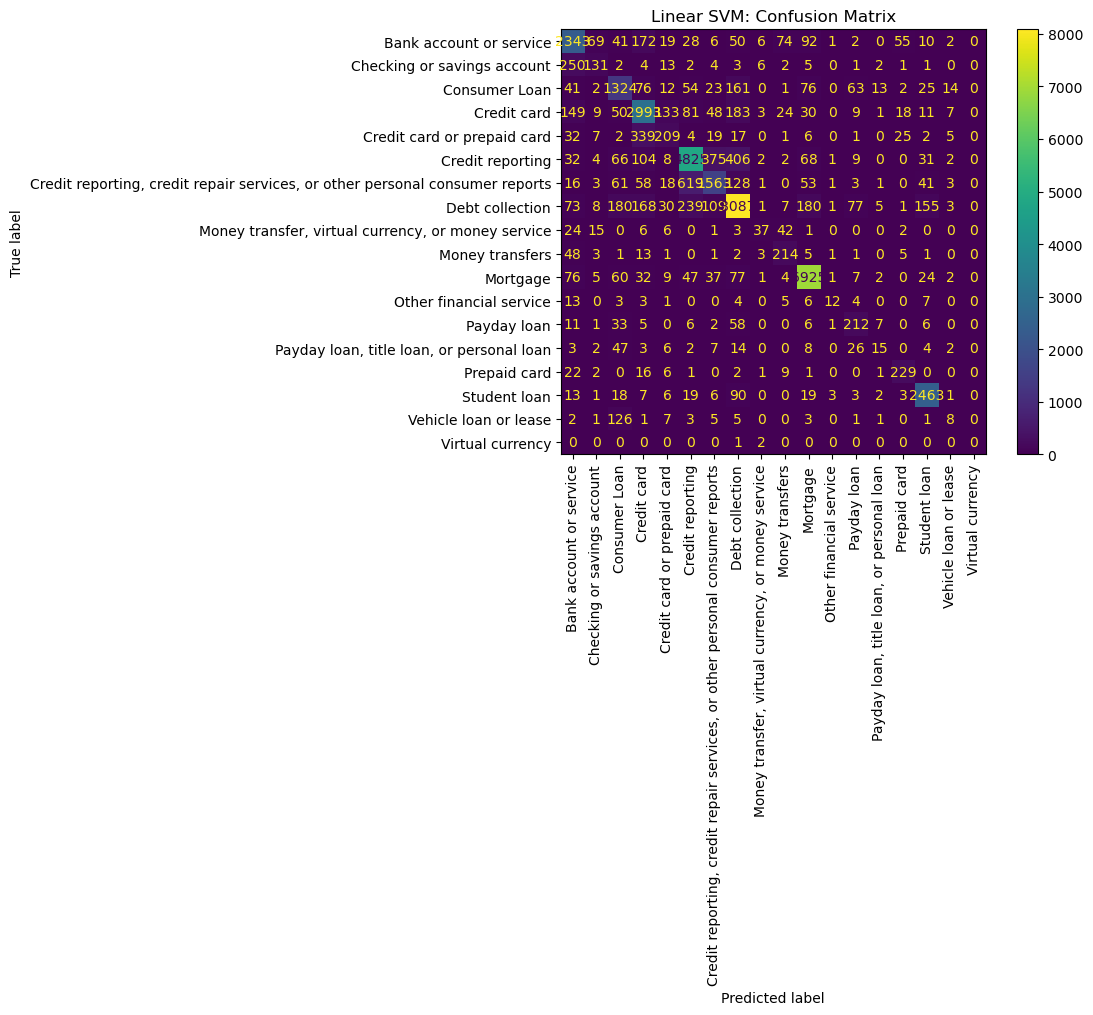

In [53]:
# Plot the confusion matrix for Linear SVM

fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_svm,
    xticks_rotation="vertical",
    values_format="d",
    ax=ax
)

ax.set_title("Linear SVM: Confusion Matrix")
plt.tight_layout()
plt.show()

> **Observation:**  
> The confusion matrix shows strong diagonal performance for several major product categories, including Debt collection, Mortgage, Credit reporting, and Student loan. However, some confusion remains between related financial categories, while minority classes show more scattered predictions. This is consistent with the lower Macro F1-score compared with the weighted F1-score.

### Model Comparison

In [54]:
# Compare the final performance of all three classification models

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes",
        "Linear SVM"
    ],
    
    "Training Accuracy": [
        accuracy_score(y_train, y_train_pred_logreg),
        accuracy_score(y_train, y_train_pred_nb),
        accuracy_score(y_train, y_train_pred_svm)
    ],
    
    "Testing Accuracy": [
        accuracy_score(y_test, y_test_pred_logreg),
        accuracy_score(y_test, y_test_pred_nb),
        accuracy_score(y_test, y_test_pred_svm)
    ],
    
    "Training Weighted F1": [
        f1_score(y_train, y_train_pred_logreg, average="weighted"),
        f1_score(y_train, y_train_pred_nb, average="weighted"),
        f1_score(y_train, y_train_pred_svm, average="weighted")
    ],
    
    "Testing Weighted F1": [
        f1_score(y_test, y_test_pred_logreg, average="weighted"),
        f1_score(y_test, y_test_pred_nb, average="weighted"),
        f1_score(y_test, y_test_pred_svm, average="weighted")
    ],
    
    "Training Macro F1": [
        f1_score(y_train, y_train_pred_logreg, average="macro"),
        f1_score(y_train, y_train_pred_nb, average="macro"),
        f1_score(y_train, y_train_pred_svm, average="macro")
    ],
    
    "Testing Macro F1": [
        f1_score(y_test, y_test_pred_logreg, average="macro"),
        f1_score(y_test, y_test_pred_nb, average="macro"),
        f1_score(y_test, y_test_pred_svm, average="macro")
    ]
})

model_comparison.round(4)

,Model,Training Accuracy,Testing Accuracy,Training Weighted F1,Testing Weighted F1,Training Macro F1,Testing Macro F1
0,Logistic Regression,0.8872,0.7898,0.8878,0.7917,0.8915,0.5618
1,Multinomial Naive Bayes,0.8583,0.7678,0.8563,0.7494,0.8774,0.4440
2,Linear SVM,0.9448,0.8114,0.9446,0.8067,0.9580,0.5526


> **Observation:**  
> Linear SVM achieved the best overall testing performance, with the highest accuracy of 0.8114 and weighted F1-score of 0.8067. Logistic Regression achieved a slightly higher Macro F1-score of 0.5618, indicating somewhat better balance across minority classes. However, considering the overall performance across the evaluation metrics, Linear SVM was selected as the final classification model.

In [55]:
# Identify misclassified test complaints and the most common prediction errors
error_analysis = pd.DataFrame({
    "Complaint": X_test.values,
    "Actual": y_test.values,
    "Predicted": y_test_pred_svm
})

# Keep only incorrectly classified complaints
misclassified = error_analysis[
    error_analysis["Actual"] != error_analysis["Predicted"]
].copy()

print(f"Total misclassified complaints: {len(misclassified)}")
print(f"Misclassification rate: {len(misclassified) / len(error_analysis):.2%}")

# Show the most common actual-to-predicted errors
common_errors = (
    misclassified
    .groupby(["Actual", "Predicted"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

common_errors

Total misclassified complaints: 7341
Misclassification rate: 18.86%


Actual                                                                        Predicted                                                                   
Credit reporting, credit repair services, or other personal consumer reports  Credit reporting                                                                619
Credit reporting                                                              Debt collection                                                                 406
                                                                              Credit reporting, credit repair services, or other personal consumer reports    375
Credit card or prepaid card                                                   Credit card                                                                     339
Checking or savings account                                                   Bank account or service                                                         250
Debt collection                    

In [56]:
# Inspect examples from the most common misclassification pairs
top_error_pairs = common_errors.head(5).index

for actual_label, predicted_label in top_error_pairs:
    print("=" * 100)
    print(f"Actual: {actual_label}")
    print(f"Predicted: {predicted_label}")
    
    examples = misclassified[
        (misclassified["Actual"] == actual_label) &
        (misclassified["Predicted"] == predicted_label)
    ].head(3)
    
    for i, (_, row) in enumerate(examples.iterrows(), start=1):
        print(f"\nExample {i}:")
        print(row["Complaint"][:1000])

Actual: Credit reporting, credit repair services, or other personal consumer reports
Predicted: Credit reporting

Example 1:
incorrect name name addresses and phone numbers i have disputed several times and it was removed but back on my report i called transunion and asked for a us rep and was given xxxx xxxx who just kept transferring me to a voicemail

Example 2:
there is wrong information in my report my present address xxxx xxxx xxxx xxxx mi xxxx please update xxxx xxxx xxxx xxxx xxxx i have paid off this account please update balance

Example 3:
i sent a copy of an ftc affidavit of identity theft and a police report to all xxxx bureaus by law they must block the information from my credit reports to date xxxx complied but equifax has only deleted on account not blocked the information they were required to and i can not tell on xxxx if it has been blocked or not
Actual: Credit reporting
Predicted: Debt collection

Example 1:
i have been reviewing my credit files and noticed that x

> **Observation:**  
> Error analysis shows that most misclassifications occur between closely related financial categories. The model frequently confuses credit reporting with related credit-report and debt-collection categories, as well as credit card categories and different types of bank accounts. These errors are understandable because many complaints contain information related to more than one financial issue, making some categories difficult to distinguish based on the complaint text alone.

### Similarity Search

In [57]:
# Transform the training complaints into TF-IDF features for similarity search
X_train_similarity = tfidf.transform(X_train)

print(f"Similarity matrix shape: {X_train_similarity.shape}")

Similarity matrix shape: (155723, 100000)


In [58]:
def find_similar_tickets(new_text, top_n=3):
    
    cleaned_text = new_text.lower()
    cleaned_text = re.sub(r"http\S+|www\S+", "", cleaned_text)
    cleaned_text = re.sub(r"[^a-z0-9\s]", " ", cleaned_text)
    cleaned_text = re.sub(r"\s+", " ", cleaned_text).strip()
    
    
    new_text_tfidf = tfidf.transform([cleaned_text])
    
   
    similarity_scores = cosine_similarity(
        new_text_tfidf,
        X_train_similarity
    ).flatten()
    
    
    top_indices = similarity_scores.argsort()[-top_n:][::-1]
    
    # Build a result table
    results = pd.DataFrame({
        "Complaint": X_train.iloc[top_indices].values,
        "Product": y_train.iloc[top_indices].values,
        "Similarity Score": similarity_scores[top_indices]
    })
    
    return results

In [59]:
# Test the similarity search with a new customer complaint
new_complaint = "I was charged twice for the same transaction."

similar_tickets = find_similar_tickets(
    new_complaint,
    top_n=3
)

similar_tickets

,Complaint,Product,Similarity Score
0,i was charged twice for a my xxxx mortgage lea...,Mortgage,0.370893
1,i disputed the information that it was incorre...,Debt collection,0.242884
2,i was hung up on twice by each person in the o...,"Payday loan, title loan, or personal loan",0.229139


> **Observation:**  
> The similarity search successfully retrieved the three most similar historical complaints for the new message. The results include the previous complaint text, its product category, and the cosine similarity score. The relatively moderate similarity scores indicate that the new complaint has limited textual overlap with the retrieved historical complaints.

In [60]:
# Test similarity search on several unseen customer complaints
test_complaints = [
    "Someone is collecting a debt from me that I do not recognize.",
    "My bank charged me an unexpected fee for using the ATM.",
    "There is incorrect information on my credit report."
]

for i, complaint in enumerate(test_complaints, start=1):
    print("=" * 100)
    print(f"Test Complaint {i}: {complaint}")
    print()
    
    results = find_similar_tickets(complaint, top_n=3)
    display(results)

Test Complaint 1: Someone is collecting a debt from me that I do not recognize.



,Complaint,Product,Similarity Score
0,someone is in my account,Credit reporting,0.320446
1,xxxx does not recognize irs form xxxx,Credit reporting,0.230168
2,i have a debt on my account for a collection a...,Debt collection,0.227274


Test Complaint 2: My bank charged me an unexpected fee for using the ATM.



,Complaint,Product,Similarity Score
0,bank charged me an overdraft fee and they char...,Payday loan,0.267777
1,overdraft fees are outrageous for the most par...,Checking or savings account,0.267193
2,the bank charged a fee for me to check my bala...,Bank account or service,0.247841


Test Complaint 3: There is incorrect information on my credit report.



,Complaint,Product,Similarity Score
0,this is incorrect information not mine,Debt collection,0.501386
1,experian will not let me dispute incorrect inf...,Credit reporting,0.420527
2,there is incorrect name and address informatio...,Credit reporting,0.382631


### Testing the Complete System

In [61]:
def analyze_new_complaint(new_text):
    # Predict the product category using the final Linear SVM model
    cleaned_text = new_text.lower()
    cleaned_text = re.sub(r"http\S+|www\S+", "", cleaned_text)
    cleaned_text = re.sub(r"[^a-z0-9\s]", " ", cleaned_text)
    cleaned_text = re.sub(r"\s+", " ", cleaned_text).strip()
    
    new_text_tfidf = tfidf.transform([cleaned_text])
    predicted_category = svm_model.predict(new_text_tfidf)[0]
    
    # Find the three most similar historical complaints
    similar_tickets = find_similar_tickets(new_text, top_n=3)
    
    print(f"Predicted category: {predicted_category}")
    print("\nMost similar historical complaints:")
    
    return similar_tickets

In [62]:
# Test the complete complaint analysis pipeline on a new message
new_complaint = "Someone is collecting a debt from me that I do not recognize."

analysis_result = analyze_new_complaint(new_complaint)

analysis_result

Predicted category: Debt collection

Most similar historical complaints:


,Complaint,Product,Similarity Score
0,someone is in my account,Credit reporting,0.320446
1,xxxx does not recognize irs form xxxx,Credit reporting,0.230168
2,i have a debt on my account for a collection a...,Debt collection,0.227274


In [63]:
# Test the complete system on multiple unseen customer complaints
new_complaints = [
    "I do not recognize this debt and a collection agency keeps contacting me.",
    "My bank charged me an unexpected fee for using the ATM.",
    "There is incorrect information on my credit report that I want to dispute.",
    "My credit card was charged twice for the same purchase."
]

for i, complaint in enumerate(new_complaints, start=1):
    print("=" * 100)
    print(f"Test Complaint {i}: {complaint}")
    
    results = analyze_new_complaint(complaint)
    display(results)

Test Complaint 1: I do not recognize this debt and a collection agency keeps contacting me.
Predicted category: Debt collection

Most similar historical complaints:


,Complaint,Product,Similarity Score
0,i sent xxxx debt validation requests to xxxx x...,Debt collection,0.332198
1,account does not belong to me i do not recogni...,Credit card,0.331359
2,i have sent xxxx debt validation letters to xx...,Debt collection,0.320792


Test Complaint 2: My bank charged me an unexpected fee for using the ATM.
Predicted category: Bank account or service

Most similar historical complaints:


,Complaint,Product,Similarity Score
0,bank charged me an overdraft fee and they char...,Payday loan,0.267777
1,overdraft fees are outrageous for the most par...,Checking or savings account,0.267193
2,the bank charged a fee for me to check my bala...,Bank account or service,0.247841


Test Complaint 3: There is incorrect information on my credit report that I want to dispute.
Predicted category: Credit reporting

Most similar historical complaints:


,Complaint,Product,Similarity Score
0,this is incorrect information not mine,Debt collection,0.362884
1,experian will not let me dispute incorrect inf...,Credit reporting,0.337086
2,there is a hard inquery on my credit report th...,Credit reporting,0.314946


Test Complaint 4: My credit card was charged twice for the same purchase.
Predicted category: Credit card

Most similar historical complaints:


,Complaint,Product,Similarity Score
0,i was charged twice for a my xxxx mortgage lea...,Mortgage,0.397255
1,to whom it may concern my name is xxxx xxxx my...,Credit card,0.274662
2,i disputed the information that it was incorre...,Debt collection,0.258354


> **Observation:**  
> The complete system was tested on four unseen customer complaints covering different financial issues. The predicted categories were consistent with the content of the new messages, including debt collection, bank account services, credit reporting, and credit card complaints. The similarity search also retrieved relevant historical complaints, although some retrieved tickets belonged to related categories because the similarity measure is based on textual overlap rather than predicted category.

### Saving Model And Vectorizer

In [64]:
os.makedirs("model", exist_ok=True)

joblib.dump(svm_model, "model/linear_svm_model.pkl")
joblib.dump(tfidf, "model/tfidf_vectorizer.pkl")

print("Model and TF-IDF vectorizer saved successfully.")

Model and TF-IDF vectorizer saved successfully.


In [65]:
# Save the historical complaints and their TF-IDF representations for similarity search
joblib.dump(
    {
        "complaints": X_train.reset_index(drop=True),
        "products": y_train.reset_index(drop=True),
        "tfidf_matrix": X_train_similarity
    },
    "model/similarity_data.pkl"
)

print("Similarity search data saved successfully.")

Similarity search data saved successfully.


### Testing The Loaded Model

In [66]:
# Load the saved model and TF-IDF vectorizer from disk
loaded_model = joblib.load("model/linear_svm_model.pkl")
loaded_tfidf = joblib.load("model/tfidf_vectorizer.pkl")

# Test the loaded model on a new complaint
test_message = "I do not recognize this debt and a collection agency keeps contacting me."

test_message_tfidf = loaded_tfidf.transform([test_message])
prediction = loaded_model.predict(test_message_tfidf)[0]

print(f"Predicted category: {prediction}")

Predicted category: Debt collection


## Final Discussion and Conclusion

### Dataset Balance
The product categories are imbalanced, with a few categories containing many more complaints than minority categories. This imbalance affects model performance, especially for less frequent classes.

### Common Problems
The most common complaint categories include Debt collection, Mortgage, Credit reporting, and related financial products. Many classification errors also occur between closely related categories.

### Best Model
Linear SVM achieved the best overall testing performance, with 81.14% accuracy and a weighted F1-score of 80.67%. Logistic Regression achieved a slightly higher Macro F1-score of 56.18%, showing somewhat better balance across minority classes. Linear SVM was selected as the final model because of its stronger overall performance.

### Difficult Classes
The most difficult classifications involve closely related categories, particularly credit reporting, debt collection, credit card categories, and bank account categories. These complaints may contain overlapping financial issues, making them difficult to distinguish from text alone.

### Overfitting
A noticeable difference exists between training and testing performance, particularly for Macro F1. This indicates some overfitting and reduced generalization to less frequent product categories.

### Is Accuracy Enough?
Accuracy alone is not sufficient for this dataset because of class imbalance. Weighted and Macro F1-scores provide additional information about overall performance and performance across minority classes.

### Failure Cases
Error analysis showed that most misclassifications occurred between semantically related categories. For example, credit reporting complaints were sometimes classified as debt collection or related credit-reporting categories. These errors are understandable because some complaints involve multiple related financial issues.

### Limitations and Future Improvements
Future improvements could include:

- Using more advanced text representations such as word and character-level features.
- Applying transformer-based language models for semantic classification.
- Exploring additional techniques for handling class imbalance.
- Improving classification of closely related product categories.
- Using a larger and more carefully labeled dataset.
- Adding confidence scores to the prediction interface.
- Expanding the Streamlit application with additional analytics and filtering features.

### Conclusion
This project demonstrates an end-to-end customer complaint analysis system using text preprocessing, TF-IDF feature extraction, machine learning classification, similarity search, and a Streamlit interface. The final system can classify unseen customer complaints and retrieve similar historical complaints, providing a practical foundation for supporting customer service workflows.